# Data

In [2]:
from data_generator import generate_dataset
import torch

In [3]:
data=generate_dataset(n_pde=1000)

# PINN

In [4]:
from networks.PINN import PINN
from loss.pinn_loss import pinn_loss

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

import torch

import os

Обучение

In [ ]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(5000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
        data["t_pde"], data["z_pde"],
        data["t_bc"], data["z_bc"], data["S_bc"],
        data["t_ic"], data["z_ic"], data["S_ic"],
        lambda_pde=3.,
        lambda_bc=1.,
        lambda_ic=1.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}, k = {pinn.k.item():.3f}, v_m = {pinn.v_m.item():.3f}")
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 4856.799805, k = -0.001, v_m = 0.001
Epoch 100 | Loss: 3635.577637, k = -0.000, v_m = 0.006
Epoch 200 | Loss: 2123.637207, k = -0.000, v_m = 0.009
Epoch 300 | Loss: 911.924927, k = -0.000, v_m = 0.034
Epoch 400 | Loss: 347.384644, k = -0.000, v_m = 0.069
Epoch 500 | Loss: 128.709564, k = -0.000, v_m = 0.133
Epoch 600 | Loss: 51.727737, k = -0.000, v_m = 0.207
Epoch 700 | Loss: 25.762119, k = -0.000, v_m = 0.281
Epoch 800 | Loss: 17.264370, k = -0.000, v_m = 0.351
Epoch 900 | Loss: 14.096029, k = -0.000, v_m = 0.413
Epoch 1000 | Loss: 12.424461, k = -0.000, v_m = 0.465
Epoch 1100 | Loss: 11.205440, k = -0.000, v_m = 0.509
Epoch 1200 | Loss: 10.180509, k = -0.000, v_m = 0.544
Epoch 1300 | Loss: 9.280699, k = 0.000, v_m = 0.573
Epoch 1400 | Loss: 8.479579, k = 0.000, v_m = 0.596
Epoch 1500 | Loss: 7.761768, k = 0.000, v_m = 0.615
Epoch 1600 | Loss: 7.116221, k = 0.000, v_m = 0.630
Epoch 1700 | Loss: 6.534237, k = 0.000, v_m = 0.642
Epoch 1800 | Loss: 6

In [9]:
S_pred = pinn.predict(data["t_data"], data["z_data"])

S_pred

tensor([[463.2260],
        [465.8422],
        [424.0441],
        [466.1202],
        [381.6075],
        [301.8586],
        [464.2017],
        [453.4258],
        [465.1792],
        [464.4053],
        [454.9247],
        [465.8204],
        [445.2242],
        [465.9624],
        [458.7402],
        [446.9525],
        [413.0036],
        [462.5865],
        [387.8688],
        [464.9719],
        [466.0152],
        [463.3747],
        [447.5381],
        [454.4124],
        [424.3777],
        [440.5540],
        [461.7928],
        [466.0966],
        [465.5931],
        [433.4132],
        [415.8859],
        [258.4436],
        [436.3822],
        [466.1227],
        [464.7114],
        [382.4831],
        [457.6245],
        [461.7206],
        [417.7681],
        [457.7887],
        [465.9456],
        [458.8324],
        [407.1505],
        [461.4447],
        [465.4153],
        [346.3217],
        [452.7074],
        [463.5615],
        [375.8457],
        [377.7330],


PINN только с pde

In [16]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(5000):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
        data["t_pde"], data["z_pde"],
        data["t_bc"], data["z_bc"], data["S_bc"],
        data["t_ic"], data["z_ic"], data["S_ic"],
        lambda_pde=3.0,
        lambda_bc=0.0,
        lambda_ic=0.0,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}, k = {pinn.k.item():.3f}, v_m = {pinn.v_m.item():.3f}")
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 0.000019, k = 0.001, v_m = 0.001
Epoch 100 | Loss: 0.000027, k = 0.000, v_m = 0.009
Epoch 200 | Loss: 0.000001, k = 0.000, v_m = 0.011
Epoch 300 | Loss: 0.000000, k = 0.000, v_m = 0.011
Epoch 400 | Loss: 0.000000, k = 0.000, v_m = 0.010
Epoch 500 | Loss: 0.000000, k = -0.000, v_m = 0.010
Epoch 600 | Loss: 0.000000, k = -0.000, v_m = 0.011
Epoch 700 | Loss: 0.000000, k = -0.000, v_m = 0.011
Epoch 800 | Loss: 0.000000, k = -0.000, v_m = 0.011
Epoch 900 | Loss: 0.000000, k = -0.000, v_m = 0.011
Epoch 1000 | Loss: 0.000000, k = -0.000, v_m = 0.012
Epoch 1100 | Loss: 0.000000, k = -0.000, v_m = 0.012
Epoch 1200 | Loss: 0.000000, k = -0.000, v_m = 0.012
Epoch 1300 | Loss: 0.000000, k = 0.000, v_m = 0.013
Epoch 1400 | Loss: 0.000000, k = 0.000, v_m = 0.013
Epoch 1500 | Loss: 0.000000, k = 0.000, v_m = 0.014
Epoch 1600 | Loss: 0.000000, k = 0.000, v_m = 0.014
Epoch 1700 | Loss: 0.000000, k = 0.000, v_m = 0.015
Epoch 1800 | Loss: 0.000000, k = 0.000, v_m = 0

In [17]:
S_pred = pinn.predict(data["t_data"], data["z_data"])

S_pred

tensor([[18.4700],
        [18.4700],
        [18.1380],
        [18.4700],
        [18.4442],
        [18.4700],
        [18.4700],
        [17.2698],
        [18.4700],
        [18.4700],
        [18.4700],
        [17.1047],
        [18.3932],
        [18.4700],
        [18.4700],
        [18.4700],
        [18.4700],
        [18.4700],
        [17.5788],
        [18.4700],
        [18.4700],
        [18.4699],
        [17.0979],
        [18.4700],
        [18.4700],
        [18.4700],
        [18.4700],
        [18.4700],
        [18.4700],
        [18.4700],
        [18.4700],
        [17.3399],
        [18.4700],
        [17.8906],
        [18.4700],
        [18.4700],
        [18.4700],
        [17.8854],
        [18.4695],
        [18.4700],
        [18.4700],
        [18.4700],
        [18.4700],
        [18.4700],
        [18.4700],
        [18.4700],
        [18.4700],
        [18.4700],
        [18.4700],
        [18.4700],
        [18.4700],
        [18.4700],
        [18.

In [18]:
S_true = data["S_true"]
S_true

tensor([[396.8754],
        [ 46.5984],
        [ 59.2192],
        [ 51.4926],
        [113.1395],
        [ 45.7839],
        [443.5224],
        [ 24.6132],
        [372.2926],
        [210.9382],
        [ 34.9507],
        [ 57.7645],
        [ 43.9051],
        [312.2937],
        [289.0657],
        [378.1280],
        [379.0959],
        [295.9105],
        [ 52.1726],
        [441.5655],
        [243.4049],
        [ 43.3734],
        [ 43.2191],
        [308.8551],
        [392.2813],
        [469.6994],
        [ 40.2381],
        [146.3786],
        [390.8802],
        [172.0599],
        [426.4020],
        [ 49.5799],
        [432.3382],
        [ 47.1745],
        [354.3738],
        [390.3928],
        [316.3244],
        [ 41.7761],
        [141.2251],
        [394.6968],
        [453.8523],
        [ 88.5731],
        [408.1755],
        [172.4007],
        [339.0696],
        [401.4428],
        [408.4712],
        [242.2557],
        [420.6210],
        [474.7722],


PINN, обученная с кэффициентами, которые мы задали

In [4]:
pinn = PINN()

optimizer = optim.Adam(pinn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(16100):
    pinn.train()
    optimizer.zero_grad()

    loss = pinn_loss(pinn,
        data["t_pde"], data["z_pde"],
        data["t_bc"], data["z_bc"], data["S_bc"],
        data["t_ic"], data["z_ic"], data["S_ic"],
        lambda_pde=1.,
        lambda_bc=1.,
        lambda_ic=1.,
    )

    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}")
        

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 11404.281250
Epoch 100 | Loss: 10000.708984
Epoch 200 | Loss: 8460.205078
Epoch 300 | Loss: 6970.335938
Epoch 400 | Loss: 5933.459961
Epoch 500 | Loss: 5433.526855
Epoch 600 | Loss: 5166.355957
Epoch 700 | Loss: 5003.835938
Epoch 800 | Loss: 4888.697266
Epoch 900 | Loss: 4799.995605
Epoch 1000 | Loss: 4679.287109
Epoch 1100 | Loss: 4550.806641
Epoch 1200 | Loss: 4419.788086
Epoch 1300 | Loss: 4272.417969
Epoch 1400 | Loss: 4136.733398
Epoch 1500 | Loss: 4004.616943
Epoch 1600 | Loss: 3859.715820
Epoch 1700 | Loss: 3725.515625
Epoch 1800 | Loss: 3583.809814
Epoch 1900 | Loss: 3449.186523
Epoch 2000 | Loss: 3319.235352
Epoch 2100 | Loss: 3180.722656
Epoch 2200 | Loss: 3052.470459
Epoch 2300 | Loss: 2929.847168
Epoch 2400 | Loss: 2805.129395
Epoch 2500 | Loss: 2684.046143
Epoch 2600 | Loss: 2568.237305
Epoch 2700 | Loss: 2454.343506
Epoch 2800 | Loss: 2364.077637
Epoch 2900 | Loss: 2242.570801
Epoch 3000 | Loss: 2137.441895
Epoch 3100 | Loss: 2030.5899

In [26]:
S_pred = pinn.predict(data["t_pde"], data["z_pde"])

In [7]:
data['S_true']

tensor([[505.1126],
        [501.8797],
        [499.2784],
        [524.5689],
        [491.9578],
        [516.9272],
        [520.8003],
        [497.4502],
        [484.7346],
        [484.3297],
        [505.2866],
        [507.3442],
        [ 50.3435],
        [512.6459],
        [497.4407],
        [525.7416],
        [506.2482],
        [473.4059],
        [496.8295],
        [513.2258],
        [493.6216],
        [499.0651],
        [504.5967],
        [500.7185],
        [494.8365],
        [500.1894],
        [500.8947],
        [500.5848],
        [490.1773],
        [495.7204],
        [491.9767],
        [516.1281],
        [509.0081],
        [503.8393],
        [499.8059],
        [509.7283],
        [501.6269],
        [498.5465],
        [483.3095],
        [515.7421],
        [518.0894],
        [499.4160],
        [504.5856],
        [496.4422],
        [503.0054],
        [507.4734],
        [503.4435],
        [496.2234],
        [501.8800],
        [504.7206],


## Проверки

In [6]:
pinn.predict(data["t_pde"], data["z_pde"]).shape, data["S_true"].shape

(torch.Size([1000, 1]), torch.Size([1000, 1]))

In [41]:
data["t_pde"].shape

torch.Size([500, 1])

In [11]:
pinn.predict(data["t_pde"], data["z_pde"]) - data["S_true"]


tensor([[ -62.2083],
        [-224.2675],
        [ -89.3925],
        [ -52.8628],
        [ -44.9615],
        [-116.1124],
        [ -93.7769],
        [ -88.3317],
        [-373.5282],
        [-156.3182],
        [ -62.2654],
        [-140.9466],
        [ -87.7956],
        [-122.0672],
        [-286.0479],
        [-362.8875],
        [-126.8527],
        [-125.1078],
        [ -97.3214],
        [ -91.6467],
        [ -79.7932],
        [-175.0670],
        [ -52.4377],
        [-143.0561],
        [-238.0062],
        [ -69.6241],
        [ -57.0014],
        [-406.9576],
        [ -90.1382],
        [-256.5820],
        [-392.1815],
        [-217.0683],
        [-299.1390],
        [-150.8586],
        [-413.0291],
        [-261.3214],
        [ -93.9039],
        [-130.9045],
        [ -59.7636],
        [-306.9514],
        [-163.2416],
        [-146.6949],
        [-193.3010],
        [-146.7491],
        [ -60.7202],
        [-434.1931],
        [ -81.5996],
        [ -99

In [11]:
pinn.forward(torch.Tensor([[1]]), torch.Tensor([[0]]))

tensor([[51.2225]], grad_fn=<AddmmBackward0>)

## Сохранение модели

In [28]:
torch.save({
    "model_state_dict": pinn.state_dict(),
    "v_m": pinn.v_m.detach(),
    "k": pinn.k.detach()
}, os.path.join('.', 'models', 'pinn.pth'))

# MDN

In [5]:
from networks.MDN import MDN
from loss.mdn_loss import mdn_loss

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

import math
import torch

In [6]:
pinn = PINN()

checkpoint = torch.load(os.path.join('.', 'models', "pinn.pth"))
pinn.load_state_dict(checkpoint["model_state_dict"])

# pinn.v_m.data = checkpoint["v_m"]
# pinn.k.data = checkpoint["k"]

pinn.eval()

PINN(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=1, bias=True)
  )
)

In [96]:
def mdn_loss(pi, mu, sigma, target):
    target = target.expand_as(mu)

    # Gaussian PDF
    coeff = 1.0 / (sigma * torch.sqrt(torch.tensor(2.0 * torch.pi)))
    exponent = torch.exp(-0.5 * ((target - mu) / sigma)**2)

    probs = coeff * exponent
    weighted = pi * probs

    # weighted имеет форму (batch_size, n_components)
    sum_over_components = torch.sum(weighted, dim=1)  # форма (batch_size,)
    print(sum_over_components.shape)



    # loss = -torch.log(sum_over_components + 1e-8)      # форма (batch_size,)
    

    loss = -torch.log(torch.sum(weighted) + 1e-6)
    loss = torch.mean(loss)           # скаляр
    
    return loss

In [19]:
def mdn_loss(pi, mu, sigma, target):
    target = target.expand_as(mu)

    log_probs = -0.5 * ((target - mu) / sigma)**2 \
                - torch.log(sigma) \
                - 0.5 * math.log(2 * math.pi)

    log_weighted = torch.log(pi) + log_probs
    # print(log_weighted)

    loss = -torch.logsumexp(log_weighted, dim=1)
    return loss.mean()

In [24]:
mdn = MDN()

optimizer = optim.Adam(mdn.parameters(), lr=0.001)

history = []

print('НАЧАЛО ОБУЧЕНИЯ PINN')
for epoch in range(20000):
    mdn.train()
    optimizer.zero_grad()

    pi, mu, sigma = mdn.forward(S_pred)

    loss = mdn_loss(pi, mu, sigma, data['S_true'])

    
    loss.backward()
    optimizer.step()

    history.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

НАЧАЛО ОБУЧЕНИЯ PINN
Epoch 0 | Loss: 251171.921875
Epoch 100 | Loss: 3909.539307
Epoch 200 | Loss: 2594.076904
Epoch 300 | Loss: 1955.744629
Epoch 400 | Loss: 1578.324707
Epoch 500 | Loss: 1327.086182
Epoch 600 | Loss: 1146.610229
Epoch 700 | Loss: 1009.964478
Epoch 800 | Loss: 902.455078
Epoch 900 | Loss: 815.358887
Epoch 1000 | Loss: 743.160461
Epoch 1100 | Loss: 682.191528
Epoch 1200 | Loss: 629.914490
Epoch 1300 | Loss: 584.514404
Epoch 1400 | Loss: 544.656616
Epoch 1500 | Loss: 509.337860
Epoch 1600 | Loss: 477.787506
Epoch 1700 | Loss: 449.403473
Epoch 1800 | Loss: 423.708282
Epoch 1900 | Loss: 400.317810
Epoch 2000 | Loss: 378.919800
Epoch 2100 | Loss: 359.257935
Epoch 2200 | Loss: 341.118408
Epoch 2300 | Loss: 324.322571
Epoch 2400 | Loss: 308.719635
Epoch 2500 | Loss: 294.180878
Epoch 2600 | Loss: 280.596802
Epoch 2700 | Loss: 267.872620
Epoch 2800 | Loss: 255.926056
Epoch 2900 | Loss: 244.685776
Epoch 3000 | Loss: 234.089264
Epoch 3100 | Loss: 224.081299
Epoch 3200 | Loss: 21

In [29]:
torch.save({
    "model_state_dict": mdn.state_dict()
}, os.path.join('.', 'models', 'mdn.pth'))

In [8]:
mdn = MDN()

checkpoint = torch.load(os.path.join('.', 'models', "mdn.pth"))
mdn.load_state_dict(checkpoint["model_state_dict"])

# pinn.v_m.data = checkpoint["v_m"]
# pinn.k.data = checkpoint["k"]

mdn.eval()

MDN(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=100, bias=True)
    (1): Tanh()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): Tanh()
  )
  (pi): Linear(in_features=100, out_features=3, bias=True)
  (mu): Linear(in_features=100, out_features=3, bias=True)
  (sigma): Linear(in_features=100, out_features=3, bias=True)
)

In [10]:
mdn.predict(S_pred)

(tensor([493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032,
         493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032,
         493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032,
         493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032,
         493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032,
         493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032,
         493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032,
         493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032,
         493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032,
         493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032,
         493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032,
         493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032, 493.0032,
         493.0032, 493.0032, 493.0032, 493.0032, 493

In [11]:
mean, lower, upper = mdn.predict(S_pred)

# График

In [29]:
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def plot_mdn_results(model, x, y_true, pinn_pred, title):
    model.eval()

    # сортировка для красивой линии
    x_sorted, indices = torch.sort(x.squeeze())
    y_true_sorted = y_true.squeeze()[indices]

    # MDN предсказания
    mean, lower, upper = model.predict(x)

    mean = mean[indices]
    lower = lower[indices]
    upper = upper[indices]

    # === plotting ===
    plt.figure(figsize=(8, 5))

    # реальные данные
    plt.scatter(x_sorted.cpu(), y_true_sorted.cpu(),
                s=10, alpha=0.5, label="Data")

    # PINN (если есть)
    if pinn_pred is not None:
        pinn_pred = pinn_pred.squeeze()[indices]
        plt.plot(x_sorted.cpu(), pinn_pred.cpu(),
                 linestyle="--", label="PINN")

    # MDN mean
    plt.plot(x_sorted.cpu(), mean.cpu(),
             linewidth=2, label="MDN mean")

    # uncertainty band
    plt.fill_between(
        x_sorted.cpu().numpy(),
        lower.cpu().numpy(),
        upper.cpu().numpy(),
        alpha=0.3,
        label="MDN ±1.96σ"
    )
    
    plt.xlabel(title)
    plt.ylabel("S")
    plt.legend()
    plt.title("MDN uncertainty visualization")

    plt.tight_layout()
    plt.show()

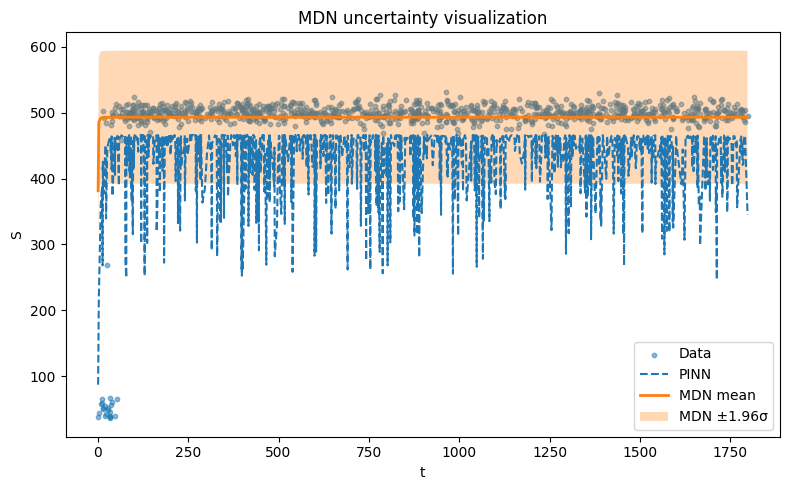

In [30]:
plot_mdn_results(
    model=mdn,
    x=data['t_data'],
    y_true=data['S_true'],
    pinn_pred=S_pred,
    title='t'
)

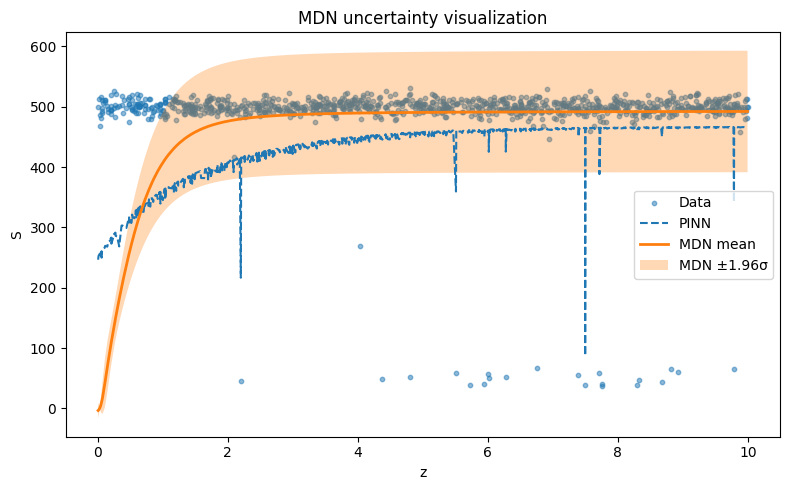

In [31]:
plot_mdn_results(
    model=mdn,
    x=data['z_data'],
    y_true=data['S_true'],
    pinn_pred=S_pred,
    title='z'
)